# 01 — Exploratory Data Analysis

Live corpus from ArXiv, PubMed, and Wikipedia APIs.

**Sources:**
- ArXiv API: https://arxiv.org/help/api/index
- PubMed E-utilities: https://www.ncbi.nlm.nih.gov/books/NBK25500/
- Wikipedia REST API: https://www.mediawiki.org/wiki/API:Main_page

**Corpus:** 968 real documents across 4 categories (medical, scientific, financial, legal).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

df = pd.read_parquet('../data/processed/cleaned_documents.parquet')
print(f'Total documents: {len(df)}')
print(f'Sources: {df["source"].nunique()}')
print(f'Categories: {df["category"].nunique()}')
print(f'Columns: {list(df.columns)}')

Total documents: 968
Sources: 3
Categories: 4
Columns: ['doc_id', 'source', 'category', 'subcategory', 'title', 'text', 'url', 'date', 'clean_text']


In [2]:
print('Category distribution:')
print(df['category'].value_counts())
print()
print('Source distribution:')
print(df['source'].value_counts())

Category distribution:
category
medical       414
scientific    356
financial     156
legal          42
Name: count, dtype: int64

Source distribution:
source
arxiv      455
pubmed     414
wikipedia   99
Name: count, dtype: int64


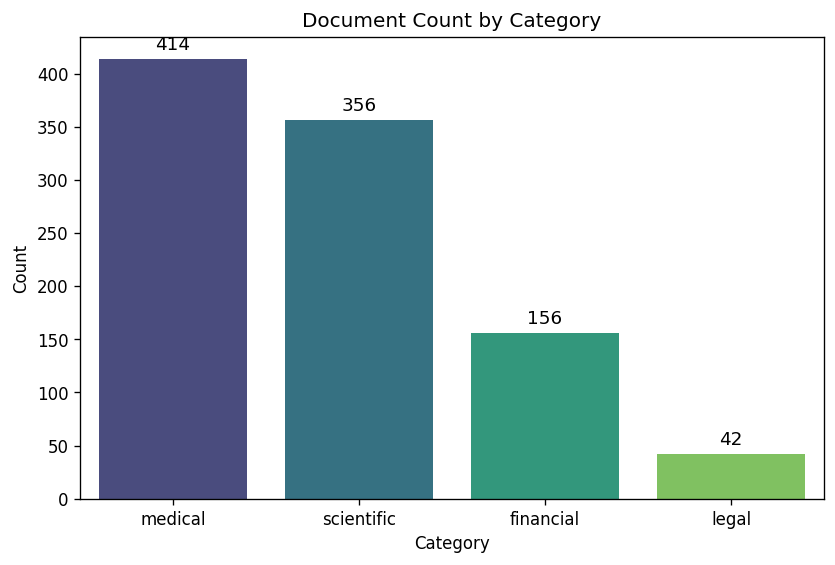

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
cat_counts = df['category'].value_counts()
sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='viridis', ax=ax, order=cat_counts.index)
ax.set_title('Document Count by Category')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

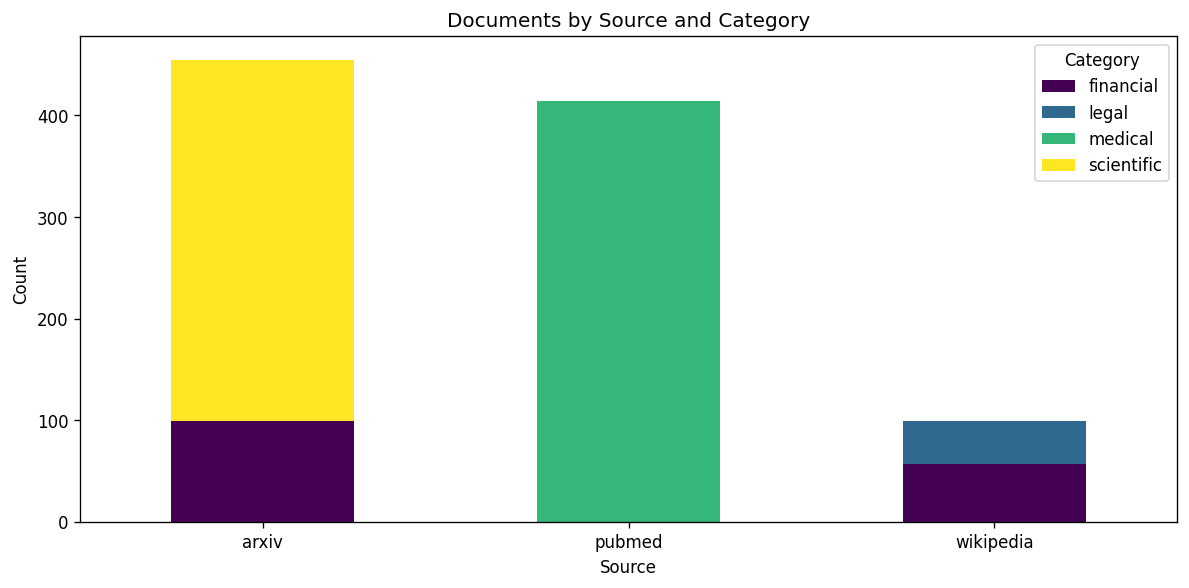

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ct = pd.crosstab(df['source'], df['category'])
ct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_title('Documents by Source and Category')
ax.set_ylabel('Count')
ax.set_xlabel('Source')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Category')
plt.tight_layout()
plt.show()

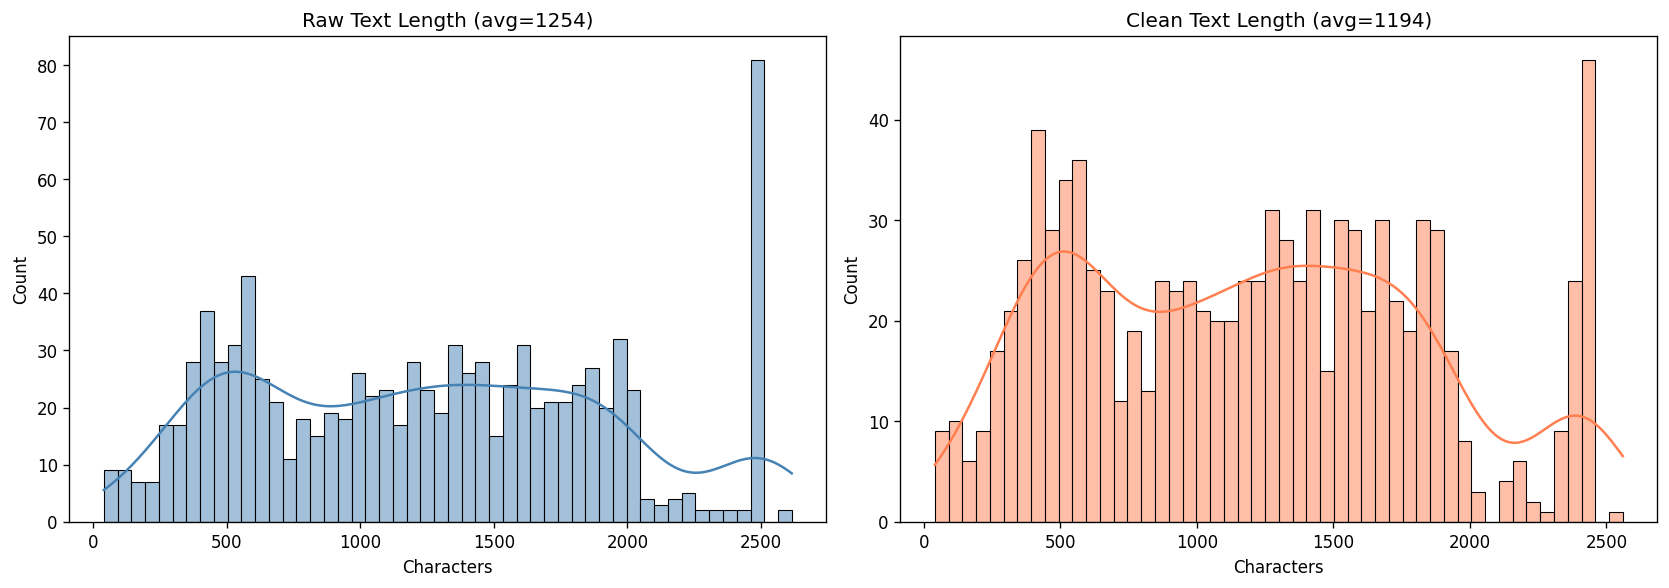

In [5]:
df['text_len'] = df['text'].str.len()
df['clean_len'] = df['clean_text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['text_len'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Raw Text Length (avg={int(df["text_len"].mean())})')
axes[0].set_xlabel('Characters')
sns.histplot(df['clean_len'], bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title(f'Clean Text Length (avg={int(df["clean_len"].mean())})')
axes[1].set_xlabel('Characters')
plt.tight_layout()
plt.show()

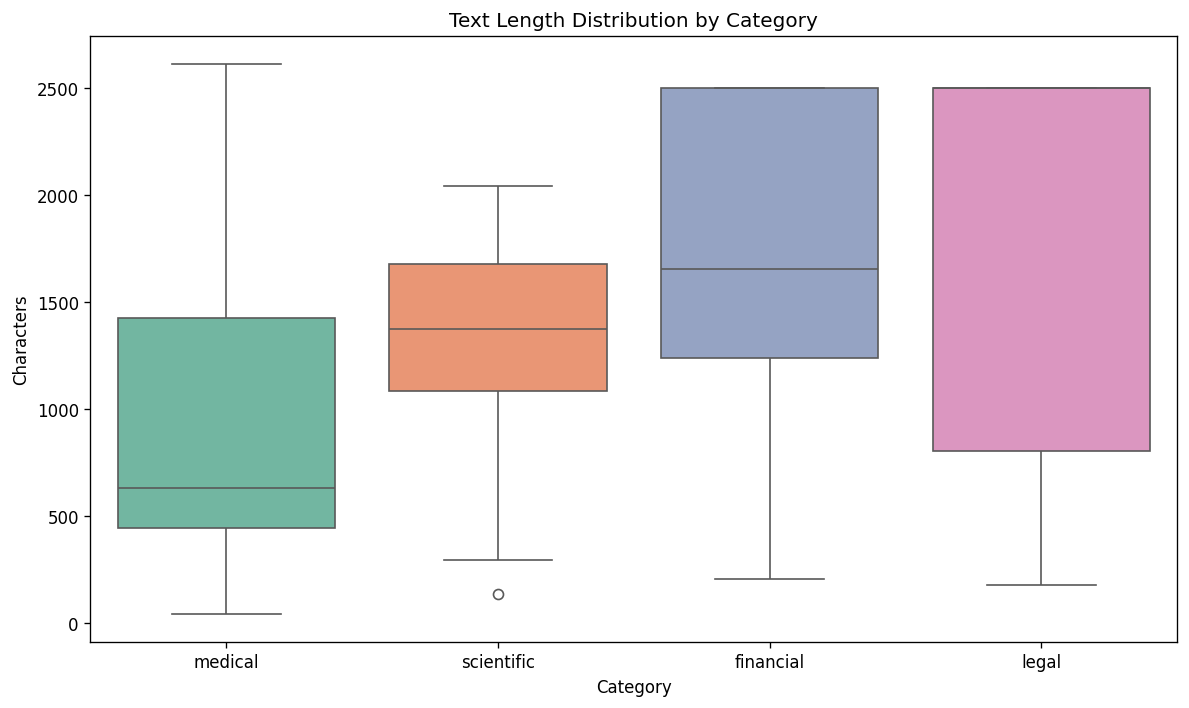

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='text_len', order=['medical','scientific','financial','legal'], palette='Set2', ax=ax)
ax.set_title('Text Length Distribution by Category')
ax.set_xlabel('Category')
ax.set_ylabel('Characters')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

vectorizer = joblib.load('../data/processed/tfidf_vectorizer.pkl')
print(f'TF-IDF vocab size: {len(vectorizer.vocabulary_)}')
print(f'Max features configured: {vectorizer.max_features}')
print(f'N-gram range: {vectorizer.ngram_range}')
feature_names = vectorizer.get_feature_names_out()
print(f'Sample features: {list(feature_names[:20])}')

TF-IDF vocab size: 5000
Max features configured: 5000
N-gram range: (1, 2)
Sample features: ['ability', 'ability to', 'able', 'able to', 'about', 'about the', 'above', 'absence', 'absence of', 'absolute', 'absorption', 'accelerating', 'accepted', 'access', 'access and', 'access to', 'accessibility', 'accompanied', 'accompanied by', 'according']


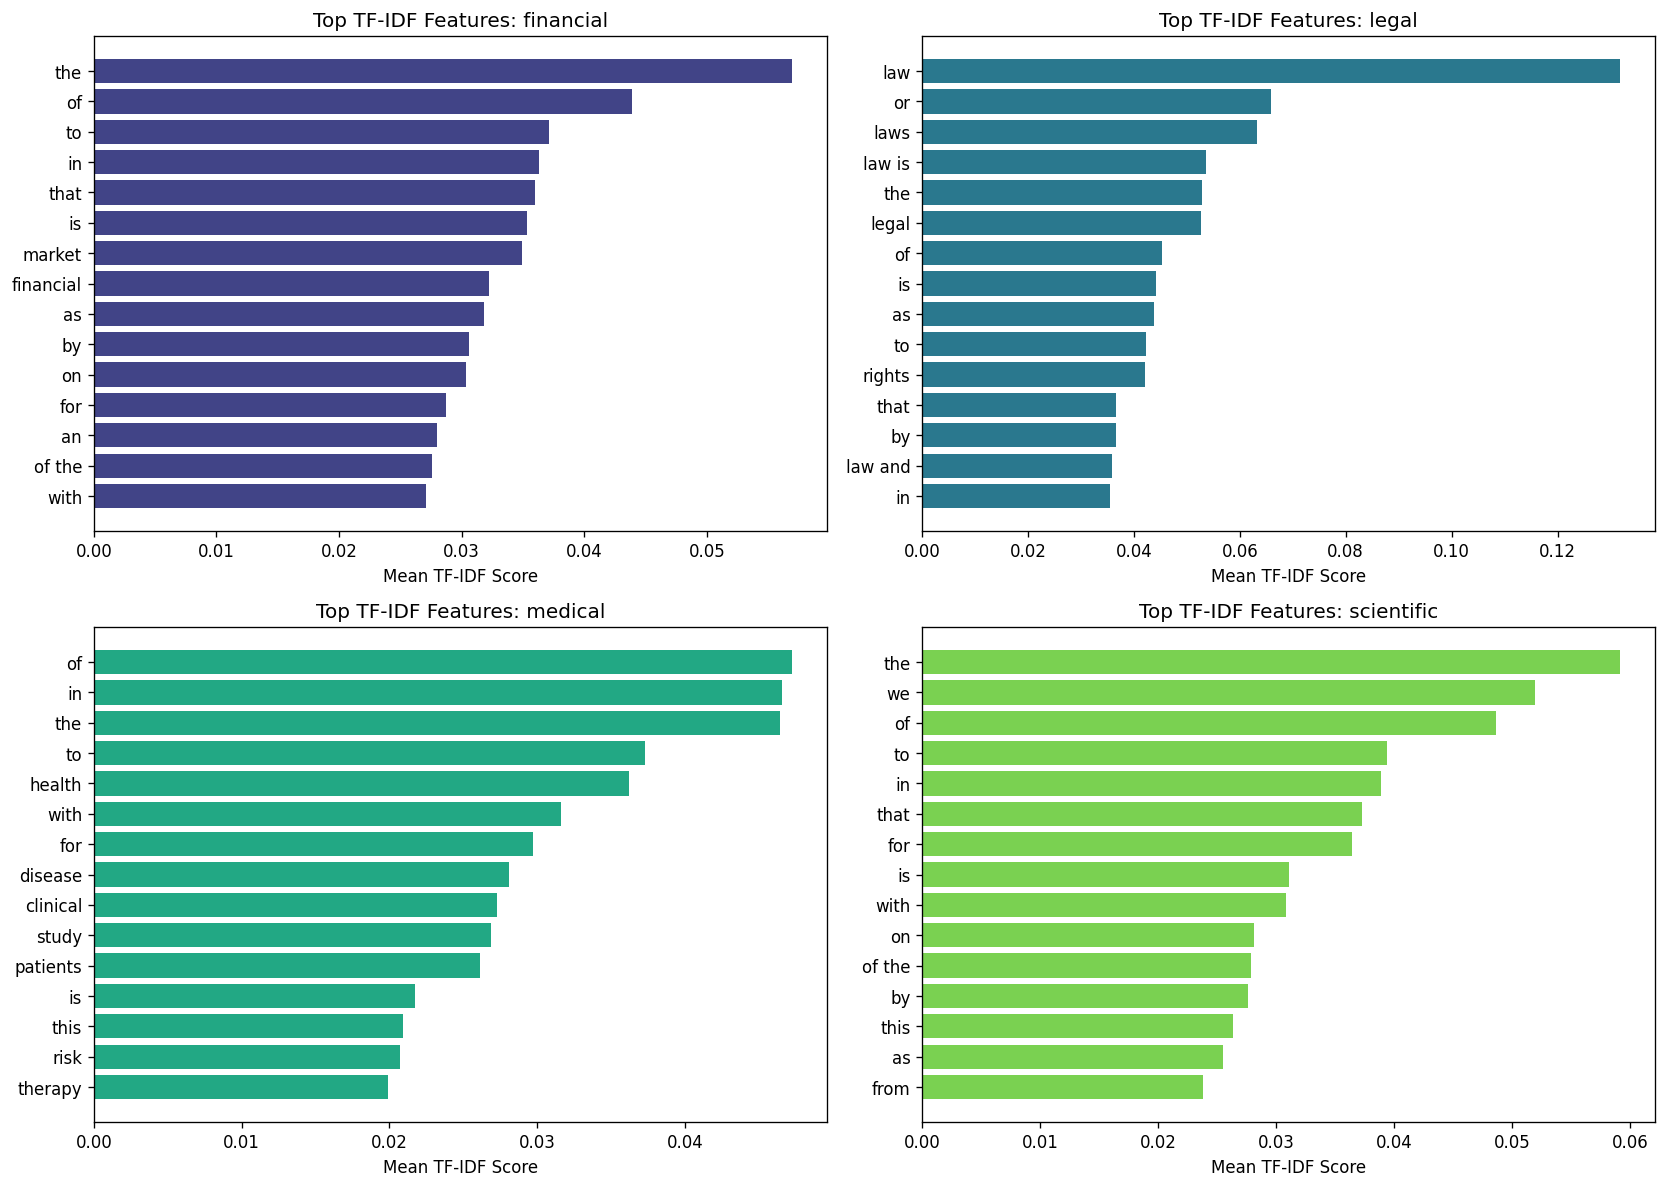

In [8]:
import joblib
from sklearn.ensemble import RandomForestClassifier

vectorizer = joblib.load('../data/processed/tfidf_vectorizer.pkl')
le = joblib.load('../data/processed/label_encoder.pkl')
feature_names = vectorizer.get_feature_names_out()
class_names = list(le.classes_)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, cls in enumerate(class_names):
    mask = df['category'] == cls
    class_tfidf = vectorizer.transform(df.loc[mask, 'clean_text'])
    mean_scores = np.asarray(class_tfidf.mean(axis=0)).flatten()
    top_idx = np.argsort(mean_scores)[-15:][::-1]
    top_features = [feature_names[i] for i in top_idx]
    top_scores = mean_scores[top_idx]
    ax = axes[idx]
    y_pos = np.arange(len(top_features))
    ax.barh(y_pos, top_scores, color=sns.color_palette('viridis', 4)[idx])
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_features)
    ax.invert_yaxis()
    ax.set_title(f'Top TF-IDF Features: {cls}')
    ax.set_xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.show()

In [9]:
summary = df.groupby('category').agg(
    count=('doc_id', 'count'),
    avg_raw_len=('text_len', 'mean'),
    avg_clean_len=('clean_len', 'mean'),
    sources=('source', lambda x: ', '.join(x.unique()))
).round(1)
print(summary)

            count  avg_raw_len  avg_clean_len           sources
category                                                       
financial     156       1749.7         1663.3  wikipedia, arxiv
legal          42       1929.0         1865.9         wikipedia
medical       414        911.5          872.7            pubmed
scientific    356       1356.4         1283.5             arxiv
